# Lecture 4 — Class Exercise
## Scatter & Bubble Charts: Gapminder

> **Push to:** `week04/lecture04_exercise.ipynb`

**Rules:**
1. Colour used **sparingly** — one categorical variable, no rainbow
2. If showing all continents, either use accessible palette OR grey all + highlight one
3. `size_max` set when using bubble size
4. Log scale for GDP per capita
5. Insight title

---


In [1]:
import pandas as pd
import plotly.express as px


# Dataset: Gapminder — GDP, Life Expectancy, Population by Country
# Source: Gapminder Foundation (gapminder.org)

df = px.data.gapminder()
print(f"Loaded: {len(df)} rows")
print(df.head())

Loaded: 1704 rows
       country continent  year  lifeExp       pop   gdpPercap iso_alpha  \
0  Afghanistan      Asia  1952   28.801   8425333  779.445314       AFG   
1  Afghanistan      Asia  1957   30.332   9240934  820.853030       AFG   
2  Afghanistan      Asia  1962   31.997  10267083  853.100710       AFG   
3  Afghanistan      Asia  1967   34.020  11537966  836.197138       AFG   
4  Afghanistan      Asia  1972   36.088  13079460  739.981106       AFG   

   iso_num  
0        4  
1        4  
2        4  
3        4  
4        4  


In [2]:
# explore

print(df.info())
print("Years:", sorted(df['year'].unique()))
print("Continents:", df['continent'].unique())
print(df.describe().round(1))


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1704 entries, 0 to 1703
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   country    1704 non-null   object 
 1   continent  1704 non-null   object 
 2   year       1704 non-null   int64  
 3   lifeExp    1704 non-null   float64
 4   pop        1704 non-null   int64  
 5   gdpPercap  1704 non-null   float64
 6   iso_alpha  1704 non-null   object 
 7   iso_num    1704 non-null   int64  
dtypes: float64(2), int64(3), object(3)
memory usage: 106.6+ KB
None
Years: [np.int64(1952), np.int64(1957), np.int64(1962), np.int64(1967), np.int64(1972), np.int64(1977), np.int64(1982), np.int64(1987), np.int64(1992), np.int64(1997), np.int64(2002), np.int64(2007)]
Continents: ['Asia' 'Europe' 'Africa' 'Americas' 'Oceania']
         year  lifeExp           pop  gdpPercap  iso_num
count  1704.0   1704.0  1.704000e+03     1704.0   1704.0
mean   1979.5     59.5  2.960121e+07     7215.3    

## Task 1 — Scatter: life expectancy change over time

**What to build:** A scatter showing **GDP per capita vs life expectancy** for **two years** (2000 and 2007) to show how both moved — use **colour for year** (just 2 colours), **one continent only**.

Choose any continent except Africa (that was the example). Highlight the change direction.

> 💡 Filter: `df.loc[df['continent'] == 'YOUR_CHOICE']` then filter years


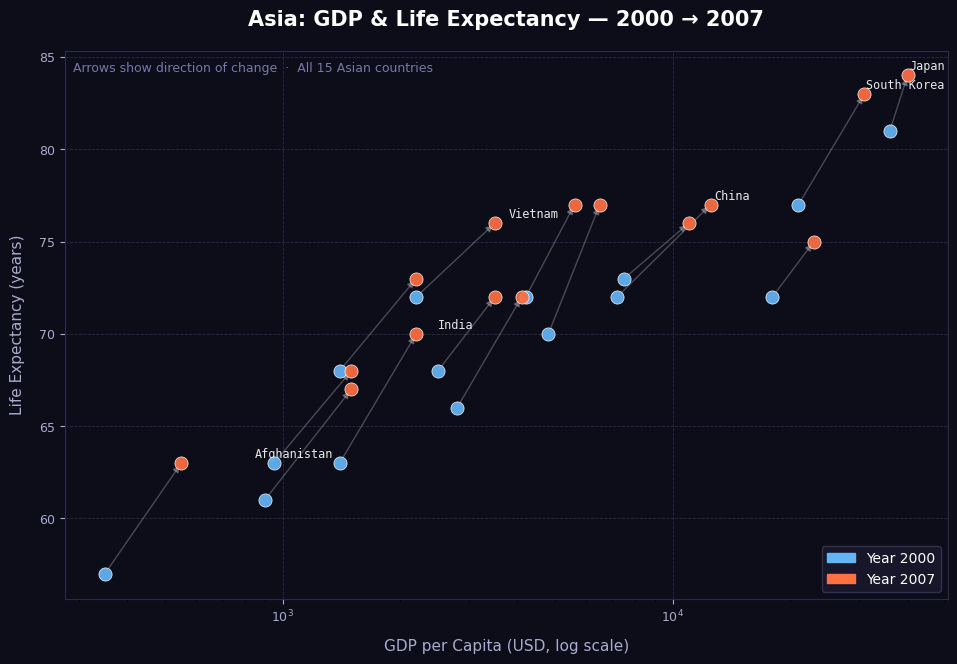

In [3]:
# Task 1
# YOUR CODE HERE
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

data = {
    "Country":  ["Afghanistan","Bangladesh","China","India","Indonesia","Iran",
                 "Japan","Malaysia","Myanmar","Pakistan","Philippines",
                 "Saudi Arabia","South Korea","Thailand","Vietnam"],
    "GDP_2007": [550,2200,12500,2200,4100,5600,40000,11000,1500,1500,3500,23000,31000,6500,3500],
    "GDP_2000": [350,1400,7200,1400,2800,4200,36000,7500,900,950,2500,18000,21000,4800,2200],
    "LE_2007":  [63,73,77,70,72,77,84,76,67,68,72,75,83,77,76],
    "LE_2000":  [57,68,72,63,66,72,81,73,61,63,68,72,77,70,72],
}

df = pd.DataFrame(data)

fig, ax = plt.subplots(figsize=(10, 7), facecolor="#0d0d1a")
ax.set_facecolor("#0d0d1a")

col_2000 = "#64b5f6"
col_2007 = "#ff7043"

for _, row in df.iterrows():
    ax.annotate("",
        xy=(row["GDP_2007"], row["LE_2007"]),
        xytext=(row["GDP_2000"], row["LE_2000"]),
        arrowprops=dict(arrowstyle="-|>", color="white", alpha=0.25, lw=1.0, mutation_scale=10))

ax.scatter(df["GDP_2000"], df["LE_2000"], color=col_2000, s=90, zorder=5,
           edgecolors="white", linewidths=0.5, alpha=0.92, label="Year 2000")
ax.scatter(df["GDP_2007"], df["LE_2007"], color=col_2007, s=90, zorder=5,
           edgecolors="white", linewidths=0.5, alpha=0.92, label="Year 2007")

label_countries = {"Japan", "China", "India", "South Korea", "Afghanistan", "Vietnam"}
for _, row in df.iterrows():
    if row["Country"] in label_countries:
        ax.text(row["GDP_2007"] + 300, row["LE_2007"] + 0.3,
                row["Country"], color="white", fontsize=8.5, fontfamily="monospace", alpha=0.9)

ax.set_xscale("log")
ax.set_xlabel("GDP per Capita (USD, log scale)", color="#aaaacc", fontsize=11, labelpad=10)
ax.set_ylabel("Life Expectancy (years)", color="#aaaacc", fontsize=11, labelpad=10)
ax.set_title("Asia: GDP & Life Expectancy — 2000 → 2007", color="white", fontsize=15, fontweight="bold", pad=18)
ax.tick_params(colors="#aaaacc", labelsize=9)
for spine in ax.spines.values():
    spine.set_edgecolor("#2a2a4a")
ax.grid(True, color="#2a2a4a", linewidth=0.6, linestyle="--")
ax.legend(handles=[
    mpatches.Patch(color=col_2000, label="Year 2000"),
    mpatches.Patch(color=col_2007, label="Year 2007"),
], facecolor="#1a1a2e", edgecolor="#3a3a5a", labelcolor="white", fontsize=10, loc="lower right")
ax.text(0.01, 0.98, "Arrows show direction of change  ·  All 15 Asian countries",
        transform=ax.transAxes, color="#7777aa", fontsize=9, va="top", ha="left")

plt.tight_layout(pad=2)
plt.savefig("chart1_scatter_asia.png", dpi=160, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()

## Task 2 — Bubble chart: tell a story

**What to build:** A bubble chart (full 2007 dataset, all countries) where:
- x = GDP per capita (log scale)
- y = life expectancy
- size = population
- colour = ONE continent highlighted (your choice), all others grey
- At least one annotation explaining the highlighted group's story

> This is the grey-and-highlight technique applied to a bubble chart.


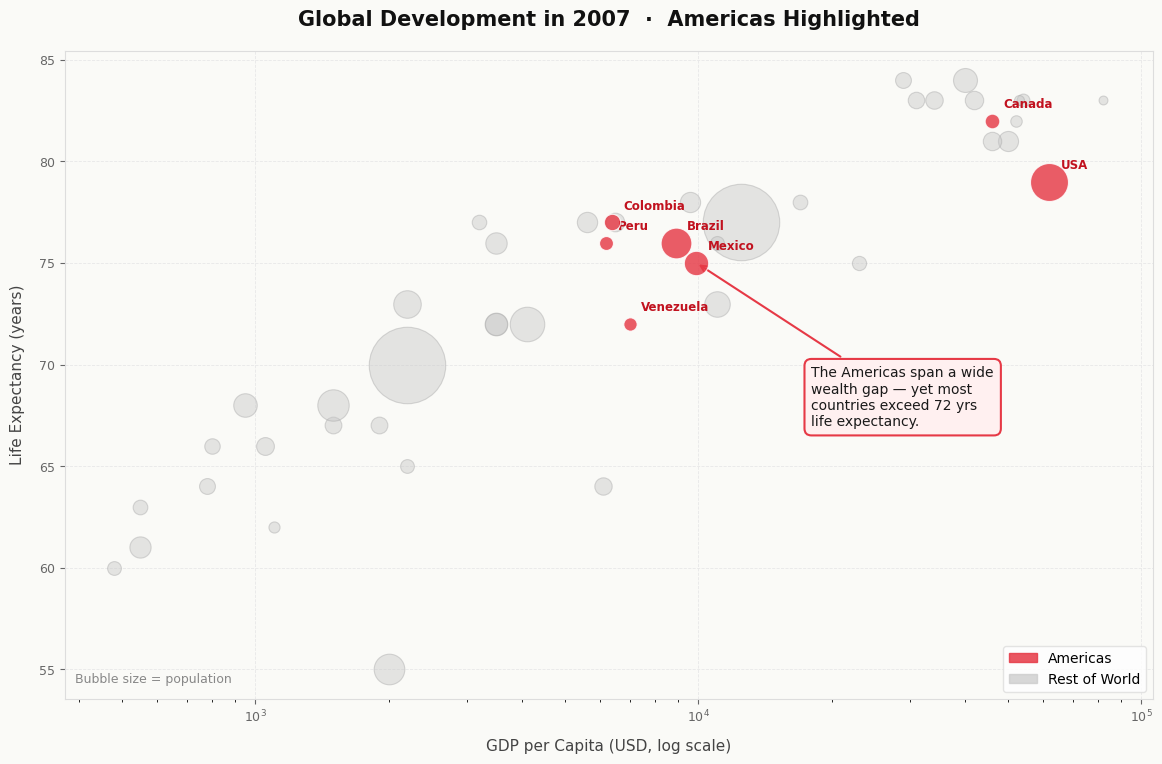

In [4]:
# Task 2
# YOUR CODE HERE
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

data = {
    "Country":   ["Afghanistan","Australia","Bangladesh","Brazil","Canada",
                  "China","Colombia","DR Congo","Egypt","Ethiopia",
                  "France","Germany","Ghana","India","Indonesia","Iran",
                  "Italy","Japan","Kenya","Malaysia","Mexico","Morocco",
                  "Mozambique","Myanmar","Netherlands","Nigeria","Norway",
                  "Pakistan","Peru","Philippines","Poland","Russia",
                  "Saudi Arabia","South Africa","South Korea","Spain",
                  "Sudan","Sweden","Tanzania","Thailand","Turkey","Uganda",
                  "UK","USA","Venezuela","Vietnam","Zimbabwe"],
    "Continent": ["Asia","Oceania","Asia","Americas","Americas",
                  "Asia","Americas","Africa","Africa","Africa",
                  "Europe","Europe","Africa","Asia","Asia","Asia",
                  "Europe","Asia","Africa","Asia","Americas","Africa",
                  "Africa","Asia","Europe","Africa","Europe",
                  "Asia","Americas","Asia","Europe","Europe",
                  "Asia","Africa","Asia","Europe",
                  "Africa","Europe","Africa","Asia","Europe","Africa",
                  "Europe","Americas","Americas","Asia","Africa"],
    "GDP":       [550,54000,2200,8900,46000,
                  12500,6400,550,3500,950,
                  42000,50000,2200,2200,4100,5600,
                  34000,40000,1900,11000,9900,3200,
                  480,1500,52000,2000,82000,
                  1500,6200,3500,17000,11000,
                  23000,6100,31000,29000,
                  800,53000,1050,6500,9600,780,
                  46000,62000,7000,3500,1100],
    "LE":        [63,83,73,76,82,
                  77,77,61,72,68,
                  83,81,65,70,72,77,
                  83,84,67,76,75,77,
                  60,67,82,55,83,
                  68,76,72,78,73,
                  75,64,83,84,
                  66,83,66,77,78,64,
                  81,79,72,76,62],
    "Pop":       [38,26,170,215,38,
                  1400,51,95,103,120,
                  68,84,32,1400,275,86,
                  60,125,54,33,130,37,
                  32,54,18,213,5,
                  225,33,111,38,144,
                  35,59,52,47,
                  44,10,63,70,85,47,
                  68,335,29,97,16],
}

df = pd.DataFrame(data)

HIGHLIGHT = "Americas"
HL_COLOR  = "#e63946"
GREY      = "#c8c8c8"

fig, ax = plt.subplots(figsize=(12, 8), facecolor="#fafaf7")
ax.set_facecolor("#fafaf7")

for _, row in df.iterrows():
    size   = (row["Pop"] / df["Pop"].max()) * 3000 + 30
    color  = HL_COLOR if row["Continent"] == HIGHLIGHT else GREY
    alpha  = 0.82 if row["Continent"] == HIGHLIGHT else 0.45
    zorder = 5 if row["Continent"] == HIGHLIGHT else 2
    ax.scatter(row["GDP"], row["LE"], s=size, color=color, alpha=alpha,
               edgecolors="white" if color == HL_COLOR else "#aaaaaa",
               linewidths=0.8, zorder=zorder)

for _, row in df[df["Continent"] == HIGHLIGHT].iterrows():
    ax.text(row["GDP"] * 1.06, row["LE"] + 0.5, row["Country"],
            color="#c1121f", fontsize=8.5, fontweight="bold", va="bottom")

ax.annotate(
    "The Americas span a wide\nwealth gap — yet most\ncountries exceed 72 yrs\nlife expectancy.",
    xy=(9900, 75), xytext=(18000, 67), fontsize=10, color="#1a1a1a",
    bbox=dict(boxstyle="round,pad=0.5", fc="#fff0f0", ec="#e63946", lw=1.5),
    arrowprops=dict(arrowstyle="->", color="#e63946", lw=1.5))

ax.set_xscale("log")
ax.set_xlabel("GDP per Capita (USD, log scale)", color="#444", fontsize=11, labelpad=10)
ax.set_ylabel("Life Expectancy (years)", color="#444", fontsize=11, labelpad=10)
ax.set_title("Global Development in 2007  ·  Americas Highlighted", color="#111", fontsize=15, fontweight="bold", pad=18)
ax.tick_params(colors="#666", labelsize=9)
for spine in ax.spines.values():
    spine.set_edgecolor("#dddddd")
ax.grid(True, color="#e8e8e8", linewidth=0.6, linestyle="--")
ax.legend(handles=[
    mpatches.Patch(color=HL_COLOR, label="Americas", alpha=0.85),
    mpatches.Patch(color=GREY,     label="Rest of World", alpha=0.7),
], facecolor="white", edgecolor="#dddddd", fontsize=10, loc="lower right")
ax.text(0.01, 0.02, "Bubble size = population", transform=ax.transAxes, color="#888", fontsize=9, va="bottom")

plt.tight_layout(pad=2)
plt.savefig("chart2_bubble_americas.png", dpi=160, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()